# MLP (Multi-layer Perceptron) with PyTorch
### Author: Krzysztof Chmielewski

This notebook demonstrates building, training, and evaluating a simple Multi-Layer Perceptron (MLP) using PyTorch on the Iris dataset. The notebook covers:
- Loading and preprocessing the dataset
- Converting data into PyTorch tensors and DataLoaders for batching
- Defining a model with `nn.Module` using `nn.Sequential` and `nn.Linear` layers with `ReLU` activation
- Training using a typical PyTorch loop (forward, compute loss, backward, optimizer step)
- Evaluating model performance via accuracy and a confusion matrix visualization

Why this example:
- The Iris dataset is small and clean — ideal for a step-by-step example
- Using PyTorch from scratch (no high-level APIs) helps demonstrate how autograd, modules, and optimizers integrate

In [1]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
import pandas as pd

import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix

## Dataset & Data Preparation

We use the Iris dataset (3 classes) provided by scikit-learn. Key points:
- Features (4): sepal length, sepal width, petal length, petal width
- Target (3 classes): setosa, versicolor, virginica

Preprocessing steps in this notebook:
- Train/test split with `train_test_split` for evaluation
- Feature scaling with `StandardScaler` to zero mean and unit variance (important for neural networks)
- Convert numpy arrays to PyTorch tensors (`dtype=torch.float32` for inputs and `torch.long` for class labels)
- Use `TensorDataset` and `DataLoader` to create batches for training and evaluation. Typical settings: `batch_size=16`, `shuffle=True` for training.

In [2]:
iris = load_iris()
X = iris.data
y = iris.target
df = pd.DataFrame(X, columns=iris.feature_names)
df['species'] = y
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=0
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

X_train = torch.tensor(X_train, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.long)
X_test = torch.tensor(X_test, dtype=torch.float32)
y_test = torch.tensor(y_test, dtype=torch.long)

train_ds = TensorDataset(X_train, y_train)
test_ds = TensorDataset(X_test, y_test)

train_loader = DataLoader(train_ds, batch_size=16, shuffle=True)
test_loader = DataLoader(test_ds, batch_size=16)

## Model Architecture & PyTorch Essentials

This MLP uses a small fully-connected architecture with ReLU activations and a final output layer producing logits for `CrossEntropyLoss`.

Mathematical form (two hidden layers):

- Hidden pre-activation and activation:
  $$ Z^{(1)} = XW^{(1)} + b^{(1)}, \quad A^{(1)} = \text{ReLU}(Z^{(1)}) $$
  $$ Z^{(2)} = A^{(1)}W^{(2)} + b^{(2)}, \quad A^{(2)} = \text{ReLU}(Z^{(2)}) $$

- Output logits and predicted probabilities:
  $$ Z^{(3)} = A^{(2)}W^{(3)} + b^{(3)} \quad (\text{logits})$$

PyTorch highlights used in this notebook:
- `nn.Module` — base class for neural nets; subclass to create a model class
- `nn.Sequential` — stack layers sequentially
- `nn.Linear(in, out)` — a fully connected linear layer with weight and bias
- `nn.ReLU()` — element-wise ReLU activation
- `nn.CrossEntropyLoss()` — computes cross-entropy for classification; accepts raw logits and integer class labels (dtype `torch.long`) and internally applies `log_softmax` followed by `nll_loss`.
- `torch.optim.Adam` — an optimizer implementing the Adam update rule; call `optimizer.step()` to apply computed gradients

Note: `CrossEntropyLoss` expects raw logits (not softmax probabilities) and labels as `LongTensor`.

In [4]:
class MLP(nn.Module):
    def __init__(self, in_features, out_features):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_features, 16),
            nn.ReLU(),
            
            nn.Linear(16,16),
            nn.ReLU(),

            nn.Linear(16,out_features)
        )
    def forward(self, x):
        return self.net(x)

## Training Loop & Backpropagation

A typical PyTorch training loop consists of:

1. Set model to training mode: `model.train()` — this enables behaviors like dropout and batch norm training mode.
2. Forward pass: compute `y_pred = model(X_batch)` and compute loss `loss = criterion(y_pred, y_batch)`.
3. Backward pass: `loss.backward()` computes gradients using autograd.
4. Parameter update: `optimizer.step()` updates parameters using gradients (e.g., Adam optimizer).
5. Reset gradients: `optimizer.zero_grad()` to clear existing gradient buffers before next iteration.

Important details:
- The loss formula for multi-class classification (Cross-Entropy Loss) is:
  $$L = -\frac{1}{N}\sum_{i=1}^{N} \log\left(\frac{e^{z_{i, y_i}}}{\sum_j e^{z_{i,j}}}\right)$$
  where $z_{i,j}$ are logits for sample $i$ and class $j$. PyTorch internally computes the softmax and log in a numerically stable way.

- Gradient accumulation: Each call to `loss.backward()` accumulates gradients into parameter `.grad` fields, so we call `optimizer.zero_grad()` before the next backward call.

In [5]:
in_features = len(iris.feature_names)
out_features = len(set(iris.target))

model = MLP(in_features, out_features)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

In [6]:
def train_model(model: nn.Module, epochs: int = 100, verbose: bool = True) -> None:

    for epoch in range(epochs):

        model.train()
        epoch_loss = 0

        for X_batch, y_batch in train_loader:
            y_pred = model(X_batch)

            loss = criterion(y_pred, y_batch)
            loss.backward()

            optimizer.step()
            optimizer.zero_grad()

            epoch_loss += loss.item()
        
        if verbose and (epoch % (epochs // 10)) == 0:
            print(f"Epoch {epoch} | Loss: {epoch_loss:.4f}")

## Evaluation & Confusion Matrix

After training, set the model to evaluation mode (`model.eval()`) and use `torch.no_grad()` to disable gradient computation. For classification, common evaluation steps include:

- Compute predicted labels by taking the `argmax` across logits: `predicted = model(X).argmax(dim=1)`
- Accuracy = number correct / total
- Visualize the confusion matrix to understand classwise performance using `sklearn.metrics.confusion_matrix` (or manual computation) and plot it with `seaborn.heatmap`.

In [7]:
def eval_model(model: nn.Module) -> float:

    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            y_pred = model(X_batch)
            predicted = y_pred.argmax(dim=1)
            correct += (predicted == y_batch).sum().item()
            total += y_batch.size(0)

    accuracy = correct / total
    print(f"Test accuracy: {accuracy:.2%}")
    return accuracy

In [8]:
def plot_eval(model: nn.Module, X, y) -> None:
    model.eval()
    y_pred = model(X).argmax(dim=1)
    cm = confusion_matrix(
        y.detach().numpy(),
        y_pred.detach().numpy()
    )

    plt.figure(figsize=(6,5))
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=iris.target_names,
        yticklabels=iris.target_names
    )
    plt.xlabel("Predicted label")
    plt.ylabel("True label")
    plt.title("Confusion Matrix")
    plt.show()

In [9]:
train_model(model)

Epoch 0 | Loss: 7.6313
Epoch 10 | Loss: 0.5922
Epoch 20 | Loss: 0.3993
Epoch 30 | Loss: 0.3488
Epoch 40 | Loss: 0.4990
Epoch 50 | Loss: 0.4610
Epoch 60 | Loss: 0.2413
Epoch 70 | Loss: 0.2066
Epoch 80 | Loss: 0.1632
Epoch 90 | Loss: 0.1422


In [10]:
eval_model(model);

Test accuracy: 96.67%


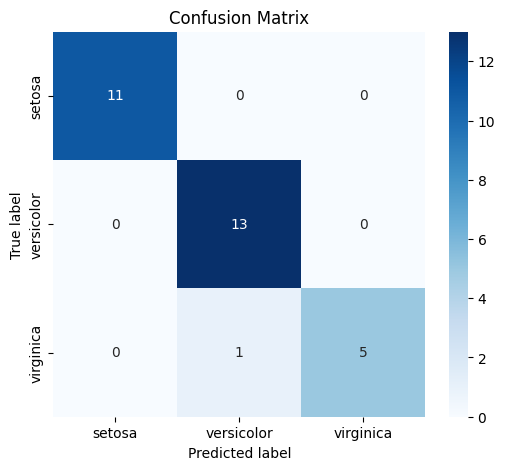

In [11]:
plot_eval(model, X_test, y_test)

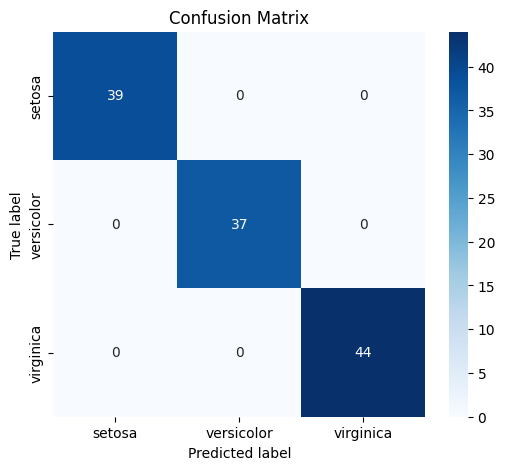

In [12]:
plot_eval(model, X_train, y_train)